In [11]:
import pandas as pd

In [12]:
df = pd.read_csv("/content/scores_data.csv")

In [13]:
df.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


In [14]:
df.shape

(149, 3)

In [15]:
df.columns

Index(['Batch ', 'User_ID ', '   Score   '], dtype='object')

In [16]:
df.columns = df.columns.str.strip()
df.columns

Index(['Batch', 'User_ID', 'Score'], dtype='object')

In [17]:
for i in df.columns:
  print(i,"-",df[i].nunique())

Batch - 3
User_ID - 149
Score - 8


In [33]:
df['Batch'].value_counts()

,count
Batch,
AI_ELITE_7,53
AI_ELITE_6,48
AI_ELITE_4,48


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Batch    149 non-null    object
 1   User_ID  149 non-null    object
 2   Score    149 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB


In [19]:
df['Score1'] = df['Score'].str.split('/').str[0].astype(float) / df['Score'].str.split('/').str[1].astype(float)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Batch    149 non-null    object 
 1   User_ID  149 non-null    object 
 2   Score    149 non-null    object 
 3   Score1   149 non-null    float64
dtypes: float64(1), object(3)
memory usage: 4.8+ KB


In [31]:
df['Score1'].describe()

,Score1
count,149.000000
mean,0.626079
std,0.227457
min,0.000000
25%,0.428571
50%,0.571429
75%,0.714286
max,1.000000


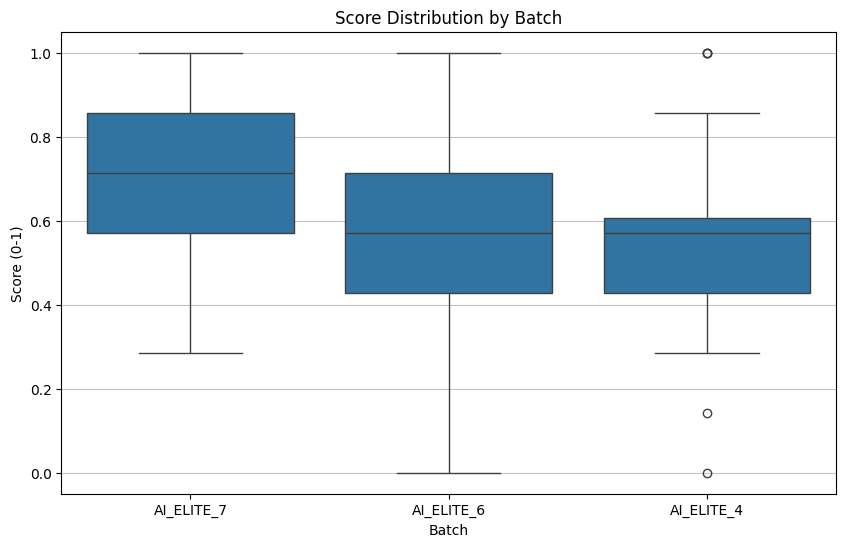

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Batch', y='Score1', data=df)
plt.title('Score Distribution by Batch')
plt.xlabel('Batch')
plt.ylabel('Score (0-1)')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [21]:
df.head()

,Batch,User_ID,Score,Score1
0,AI_ELITE_7,uid_149,6 / 7,0.857143
1,AI_ELITE_7,uid_148,6 / 7,0.857143
2,AI_ELITE_7,uid_147,7 / 7,1.000000
3,AI_ELITE_7,uid_146,7 / 7,1.000000
4,AI_ELITE_7,uid_145,4 / 7,0.571429


In [22]:
avg_scores = df.groupby('Batch')["Score1"].mean()
avg_scores

,Score1
Batch,
AI_ELITE_4,0.541667
AI_ELITE_6,0.604167
AI_ELITE_7,0.722372


Text(0.5, 1.0, 'average score of each batch')

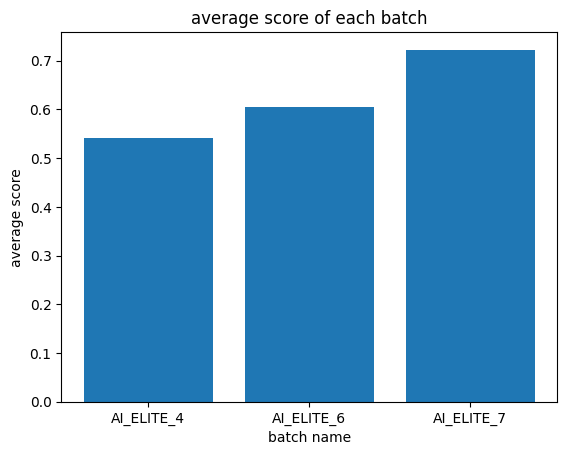

In [23]:
import matplotlib.pyplot as plt

plt.bar(avg_scores.index,avg_scores[:])
plt.xlabel("batch name")
plt.ylabel("average score")
plt.title("average score of each batch")

## **AI_ELITE_7** batch performs better than others . This could be due to various factors such as teaching methods , learning resources for that batch .

In [24]:
lt_30_percent = df[df['Score1'] < 0.30]
students_lt_30_by_batch = lt_30_percent.groupby('Batch')['User_ID'].nunique()
students_lt_30_by_batch

,User_ID
Batch,
AI_ELITE_4,9
AI_ELITE_6,6
AI_ELITE_7,2


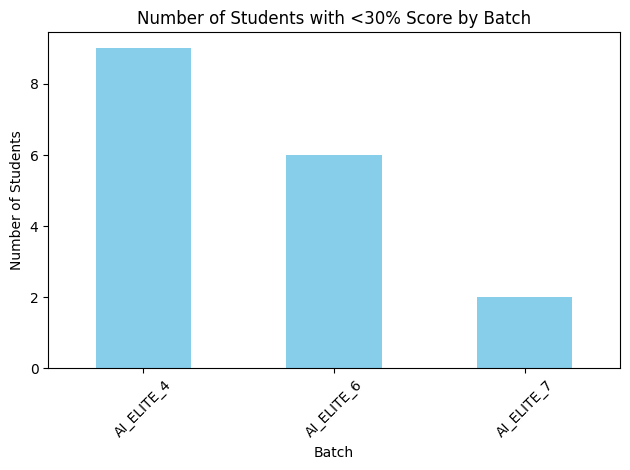

In [25]:
import matplotlib.pyplot as plt

students_lt_30_by_batch.plot(kind='bar', color='skyblue')
plt.title('Number of Students with <30% Score by Batch')
plt.xlabel('Batch')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  It suggests that **AI_ELITE_7** not only has a higher overall average but also fewer struggling students compared to the other batches
## More focus should be put on **ELITE_6 , ELITE_4**

In [26]:
zero_scored = df[df['Score1']==0]
zero_scored

,Batch,User_ID,Score,Score1
68,AI_ELITE_6,uid_81,0 / 7,0.0
135,AI_ELITE_4,uid_14,0 / 7,0.0


## one student from each batch(**ELITE_4, ELITE_6**) were not able to score atleast 1 mark

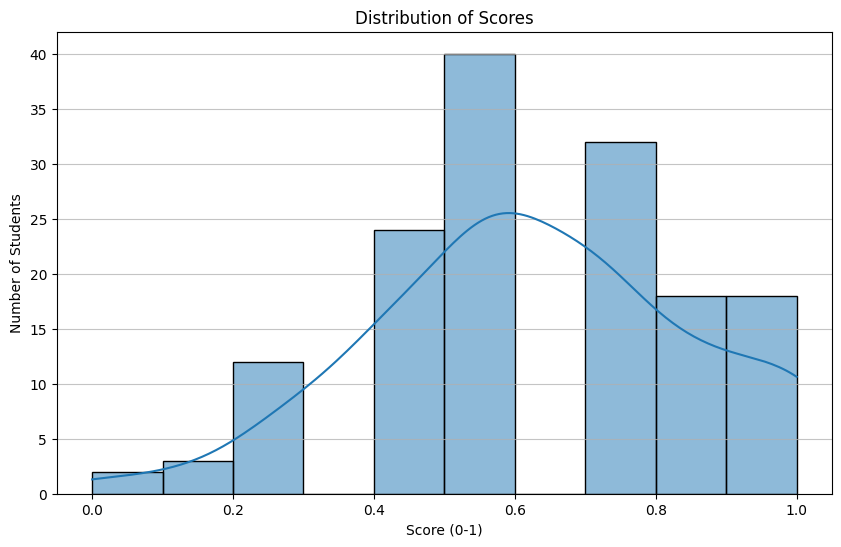

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Score1'], bins=10, kde=True)
plt.title('Distribution of Scores')
plt.xlabel('Score (0-1)')
plt.ylabel('Number of Students')
plt.grid(axis='y', alpha=0.75)
plt.show()

## There are fewer students in the lower score ranges, suggesting that most students performed reasonably well.